# Loading packages

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from prophet.plot import plot_plotly
import plotly.offline as py
py.init_notebook_mode()
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Loading the data

In [2]:
INPUT_DIR = '../data/'
calendar = pd.read_csv(f'{INPUT_DIR}/calendar.csv')
selling_prices = pd.read_csv(f'{INPUT_DIR}/sell_prices.csv')
sales_train_val = pd.read_csv(f'{INPUT_DIR}/sales_train_validation.csv')
sales_train_eval = pd.read_csv(f'{INPUT_DIR}/sales_train_evaluation.csv')

In [3]:
print(calendar.shape)
calendar.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [4]:
print(selling_prices.shape)
selling_prices.head()

(6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [5]:
print(sales_train_val.shape)
sales_train_val.head()

(30490, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [6]:
print(sales_train_eval.shape)
sales_train_eval.head()


(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [7]:
day_cols = sales_train_val.columns[sales_train_val.columns.str.contains("d_")].values
ids_cols = sales_train_val.columns[sales_train_val.columns.str.contains("d_")==False].values

In [22]:
print(ids_cols.shape)
ids_cols

(6,)


array(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
      dtype=object)

In [8]:
sales_train_val[day_cols]

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,0,0,0,0,0,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,0,0,0,0,0,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,0,0,2,2,0,3,1,4,1,0,...,2,0,0,0,0,0,1,0,0,1
30486,0,0,0,0,0,5,0,1,1,3,...,0,0,0,0,0,0,0,0,1,0
30487,0,6,0,2,2,4,1,8,5,2,...,2,1,0,2,0,1,0,0,1,0
30488,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,3,1,3


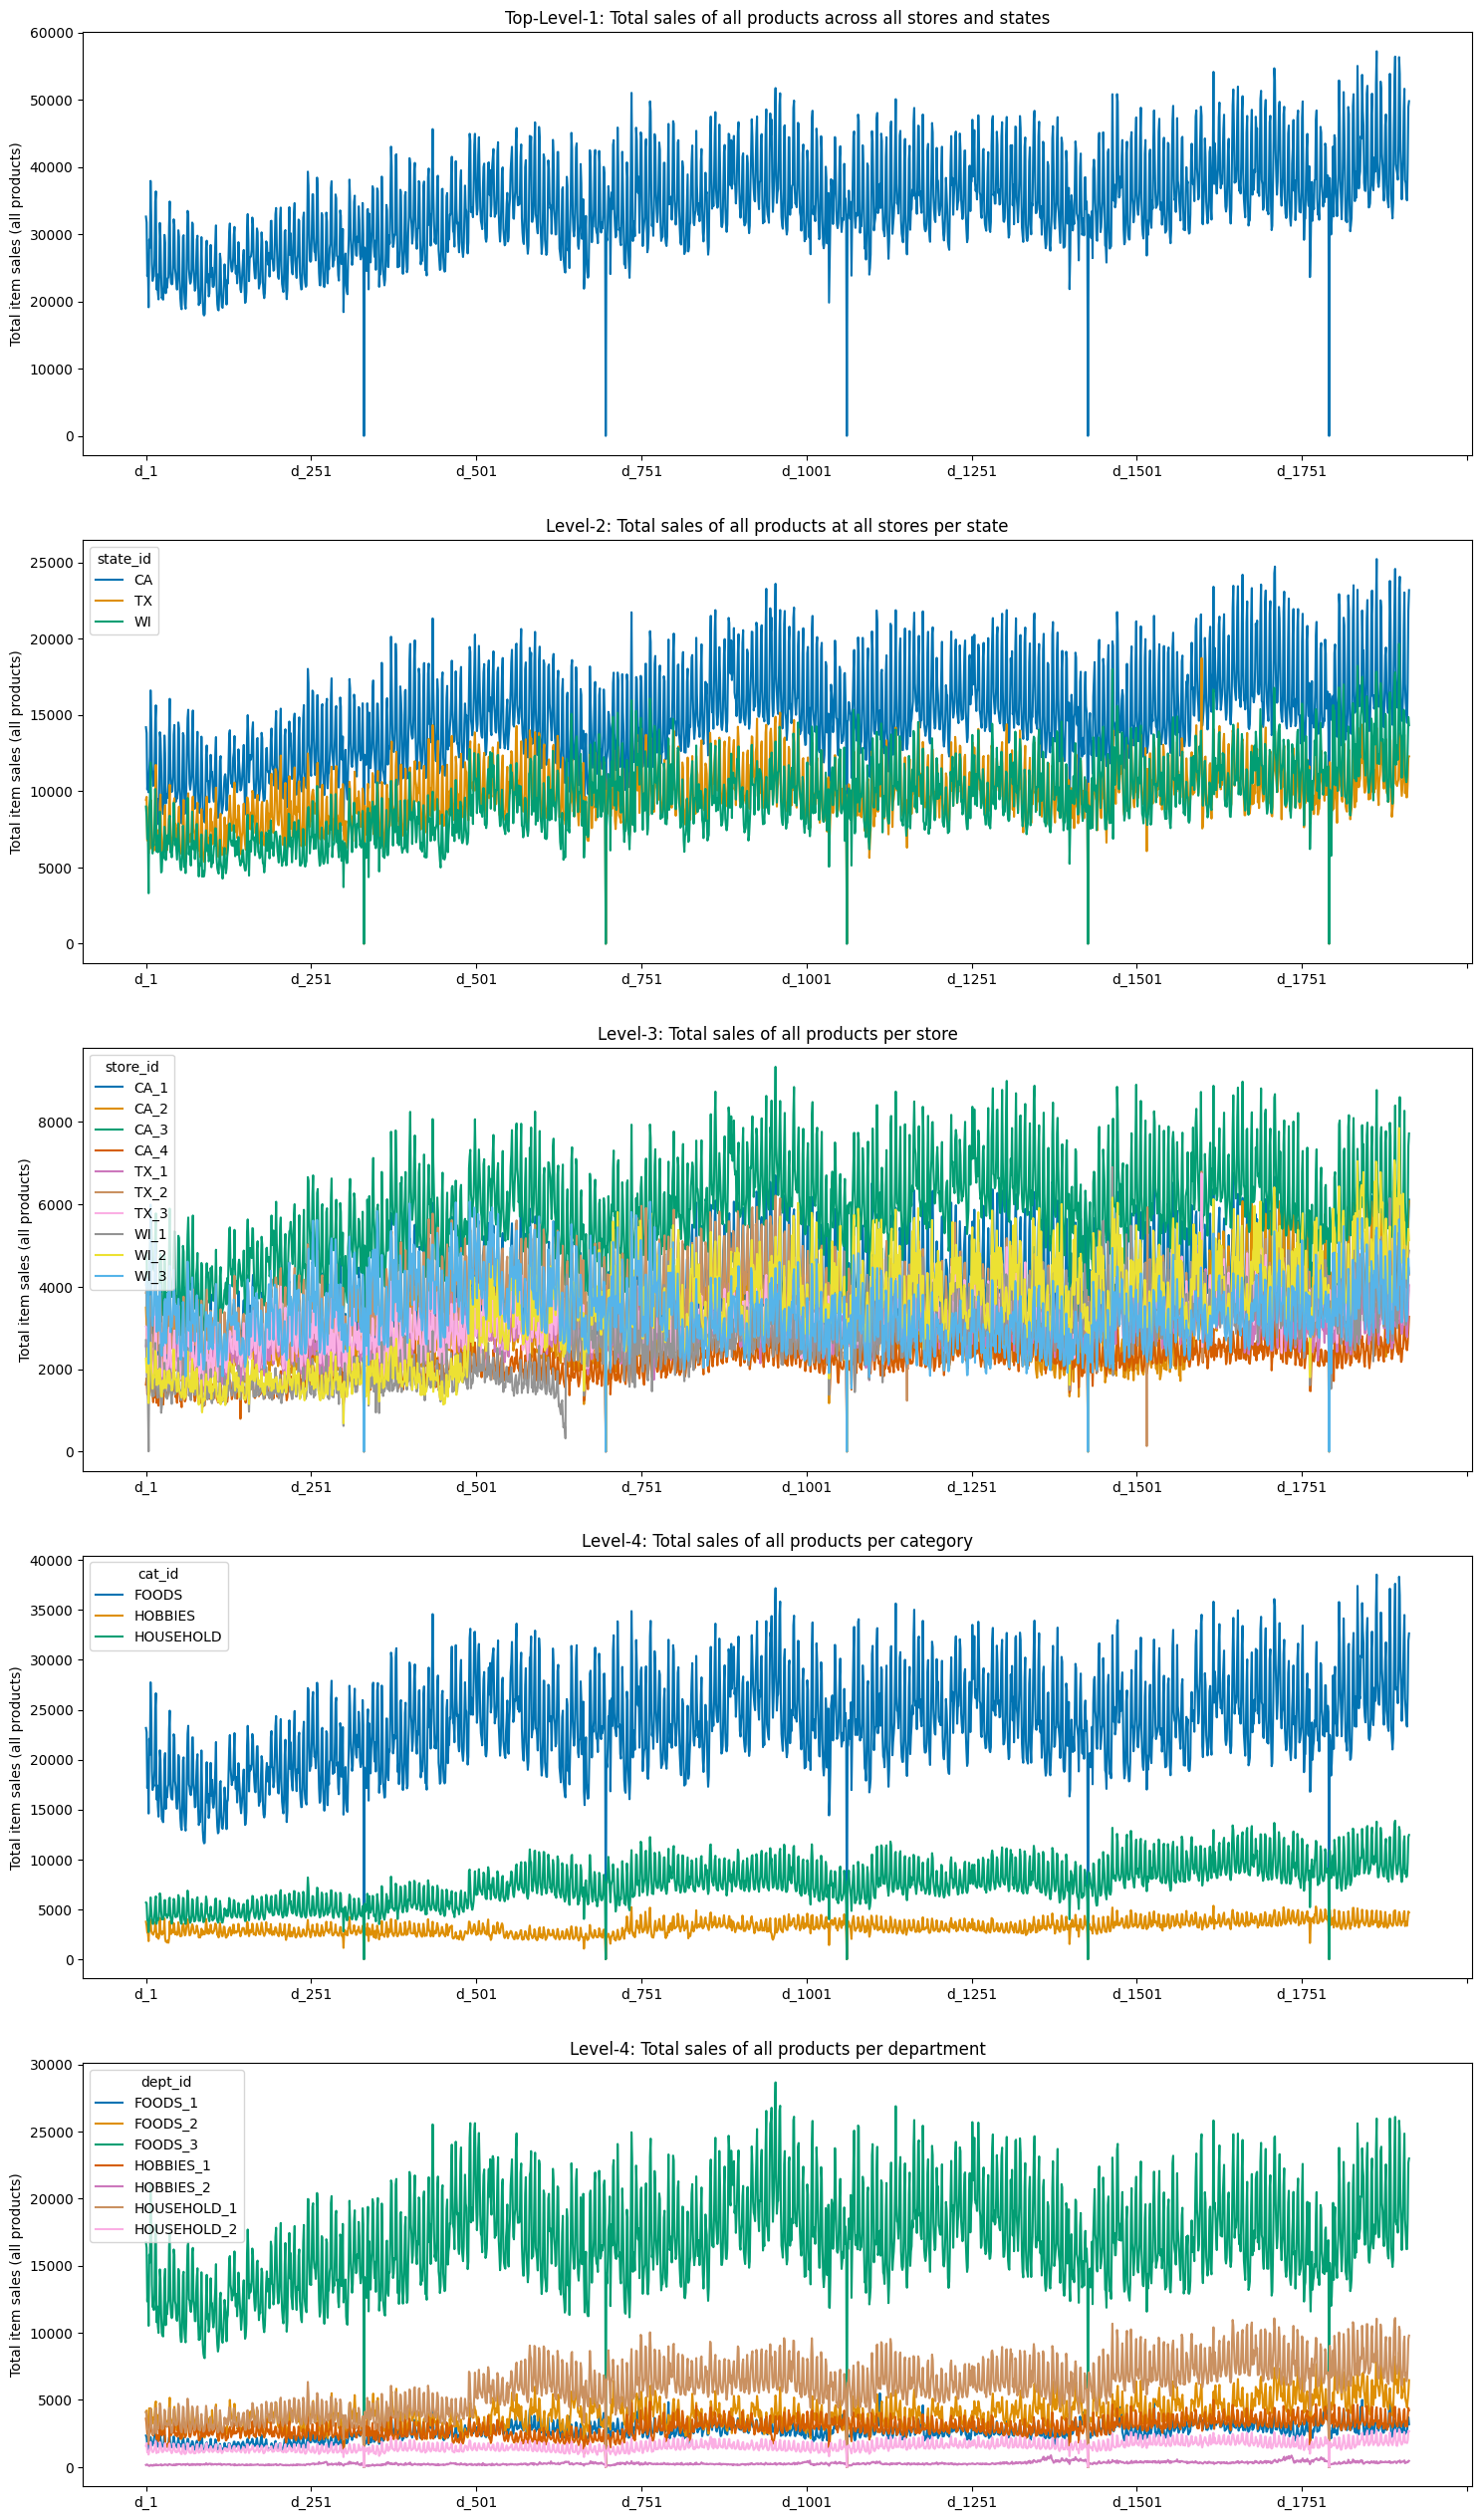

In [9]:
sns.set_palette("colorblind")

fig, ax = plt.subplots(5,1,figsize=(18,32))
sales_train_val[day_cols].sum().plot(ax=ax[0])
ax[0].set_title("Top-Level-1: Total sales of all products across all stores and states")
ax[0].set_ylabel("Total item sales (all products)");
sales_train_val.groupby("state_id")[day_cols].sum().transpose().plot(ax=ax[1])
ax[1].set_title("Level-2: Total sales of all products at all stores per state");
ax[1].set_ylabel("Total item sales (all products)");
sales_train_val.groupby("store_id")[day_cols].sum().transpose().plot(ax=ax[2])
ax[2].set_title("Level-3: Total sales of all products per store")
ax[2].set_ylabel("Total item sales (all products)");
sales_train_val.groupby("cat_id")[day_cols].sum().transpose().plot(ax=ax[3])
ax[3].set_title("Level-4: Total sales of all products per category")
ax[3].set_ylabel("Total item sales (all products)");
sales_train_val.groupby("dept_id")[day_cols].sum().transpose().plot(ax=ax[4])
ax[4].set_title("Level-4: Total sales of all products per department")
ax[4].set_ylabel("Total item sales (all products)");

# Prophet

The goal here is to predict the last month of total sales in the train_eval dataset

In [11]:
time_series = sales_train_val[day_cols].sum().values
len(time_series)

1913

In [12]:
time_series

array([32631, 31749, 23783, ..., 40517, 48962, 49795])

### Split the time series to training and validation subsets

In [14]:
train_time_series = time_series[0:-30]
eval_time_series = time_series[-30::]
print(len(train_time_series), len(eval_time_series))
days = np.arange(1, len(day_cols)+1)

1883 30


Let us plot the total sales for each day

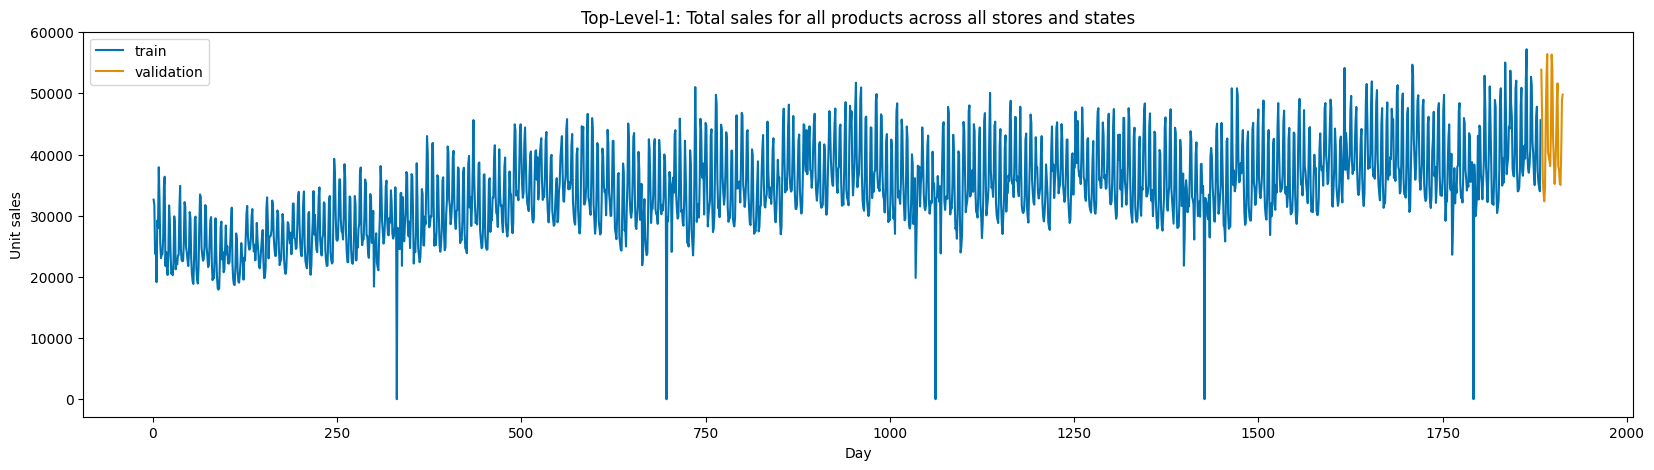

In [15]:
plt.figure(figsize=(20,5))
plt.plot(days[0:-30], train_time_series, label="train")
plt.plot(days[-30::], eval_time_series, label="validation")
plt.title("Top-Level-1: Total sales for all products across all stores and states");
plt.legend()
plt.xlabel("Day")
plt.ylabel("Unit sales");

Now, I will convert the days to actual dates using `calendar.csv`

In [24]:
dates = calendar.iloc[0:len(time_series)].date.values
df = pd.DataFrame(dates, columns=["ds"])
df.loc[:, "y"] = time_series
df.head()

,ds,y
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146


In [25]:
train_df = df.iloc[0:-30]
train_df.shape

(1883, 2)

In [31]:
eval_df = df.iloc[-30:]
eval_df.shape

(30, 2)

In [32]:
uncertainty_interval_width = 0.1

In [34]:
m = Prophet(interval_width=uncertainty_interval_width)
m.fit(train_df)
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)
forecast.head()

17:10:26 - cmdstanpy - INFO - Chain [1] start processing
17:10:27 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-01-29,23479.242084,29937.406767,30876.610617,23479.242084,23479.242084,6944.854223,6944.854223,6944.854223,7173.910351,7173.910351,7173.910351,-229.056129,-229.056129,-229.056129,0.0,0.0,0.0,30424.096307
1,2011-01-30,23492.802415,29803.224881,30620.508940,23492.802415,23492.802415,6607.195431,6607.195431,6607.195431,6747.495994,6747.495994,6747.495994,-140.300563,-140.300563,-140.300563,0.0,0.0,0.0,30099.997846
2,2011-01-31,23506.362746,21698.442635,22487.171755,23506.362746,23506.362746,-1488.605370,-1488.605370,-1488.605370,-1439.248814,-1439.248814,-1439.248814,-49.356556,-49.356556,-49.356556,0.0,0.0,0.0,22017.757376
3,2011-02-01,23519.923076,19355.127003,20179.479244,23519.923076,23519.923076,-3901.158801,-3901.158801,-3901.158801,-3944.869167,-3944.869167,-3944.869167,43.710366,43.710366,43.710366,0.0,0.0,0.0,19618.764275
4,2011-02-02,23533.483407,18952.493133,19807.738276,23533.483407,23533.483407,-4149.595876,-4149.595876,-4149.595876,-4288.280989,-4288.280989,-4288.280989,138.685113,138.685113,138.685113,0.0,0.0,0.0,19383.887531


In [35]:
col_int = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
forecast[col_int].head()

,ds,yhat,yhat_lower,yhat_upper
0,2011-01-29,30424.096307,29937.406767,30876.610617
1,2011-01-30,30099.997846,29803.224881,30620.508940
2,2011-01-31,22017.757376,21698.442635,22487.171755
3,2011-02-01,19618.764275,19355.127003,20179.479244
4,2011-02-02,19383.887531,18952.493133,19807.738276


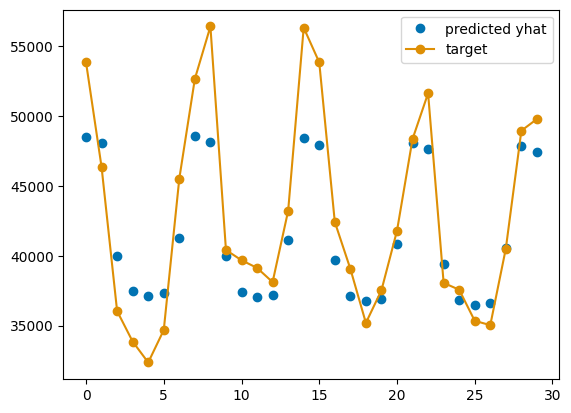

In [36]:
plt.plot(forecast.iloc[-30::].yhat.values, 'o', label="predicted yhat")
plt.plot(eval_df.y.values, 'o-', label="target")
plt.legend();

In [39]:
fig = plot_plotly(m, forecast)  
py.iplot(fig)

# LSTM

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [60]:
if not torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

device

device(type='cpu')

In [61]:
class MyLSTM(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, batch_size, num_layers=1, output_dim=1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.batch_size = batch_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size=self.input_dim,
                            hidden_size=self.hidden_dim,
                            num_layers=self.num_layers,
                            dropout = 0.25)
        self.linear = nn.Linear(self.hidden_dim, output_dim)
        
    def init_hidden(self):
        self.h_zero = torch.zeros(self.num_layers, self.batch_size, self.hidden_dim).to(device)
        self.c_zero = torch.zeros(self.num_layers, self.batch_size, self.hidden_dim).to(device)
    
    def forward(self, x):
        lstm_output, (h_n, c_n) = self.lstm(x.view(len(x), self.batch_size, -1),
                                           (self.h_zero, self.c_zero))
        last_time_step = lstm_output.view(self.batch_size, len(x), self.hidden_dim)[-1]
        pred = self.linear(last_time_step)
        return pred
    

def train_model(model, data_dict, lr=1e-4, num_epochs=500):
    
    loss_fun = torch.nn.MSELoss(reduction="mean")
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = np.zeros(num_epochs)
    phases = ["train", "eval"]
    losses_dict = {"train": [], "eval": []}
    predictions_dict = {"train": [], "eval": [] }
    
    for n in range(num_epochs):
        
        for phase in phases:
            
            x = data_dict[phase]["input"].to(device, dtype=torch.float)
            y = data_dict[phase]["target"].to(device, dtype=torch.float)
            
            if phase == "train":
                model.train()
            else:
                model.eval()
        
            optimiser.zero_grad()
            
            model.init_hidden()
            y_pred = model(x)
            
            if n == (num_epochs-1):
                predictions_dict[phase] = y_pred.float().cpu().detach().numpy()
            
            loss = loss_fun(y_pred.float(), y)
            losses_dict[phase].append(loss.item())
            
            if n % 50 == 0:
                print("{} loss: {}".format(phase, loss.item()))
            
            if phase == 'train':
                loss.backward()
                optimiser.step()
        
    return losses_dict, predictions_dict

def create_sequences(timeseries, seq_len):
    inputs = []
    targets = []
    
    max_steps = len(timeseries) - (seq_len+1)
    
    for t in range(max_steps):
        x = timeseries[t:(t+seq_len)]
        y = timeseries[t+seq_len]
        inputs.append(x)
        targets.append(y)
    
    return np.array(inputs), np.array(targets)

## The top timeseries - preprocessing <a class="anchor" id="preprocessing"></a>

Let's use the timeseries of total unit sales as an example again. For preprocessing we should remove the trend and scale the values.

In [62]:
diff_series = np.diff(time_series)
train_size = int(0.7 * len(diff_series))
train_diff_series = diff_series[0:train_size]
eval_diff_series = diff_series[train_size::]
scaler = MinMaxScaler(feature_range=(-1,1))
scaled_train = scaler.fit_transform(train_diff_series.reshape(-1, 1))
scaled_eval = scaler.transform(eval_diff_series.reshape(-1,1))

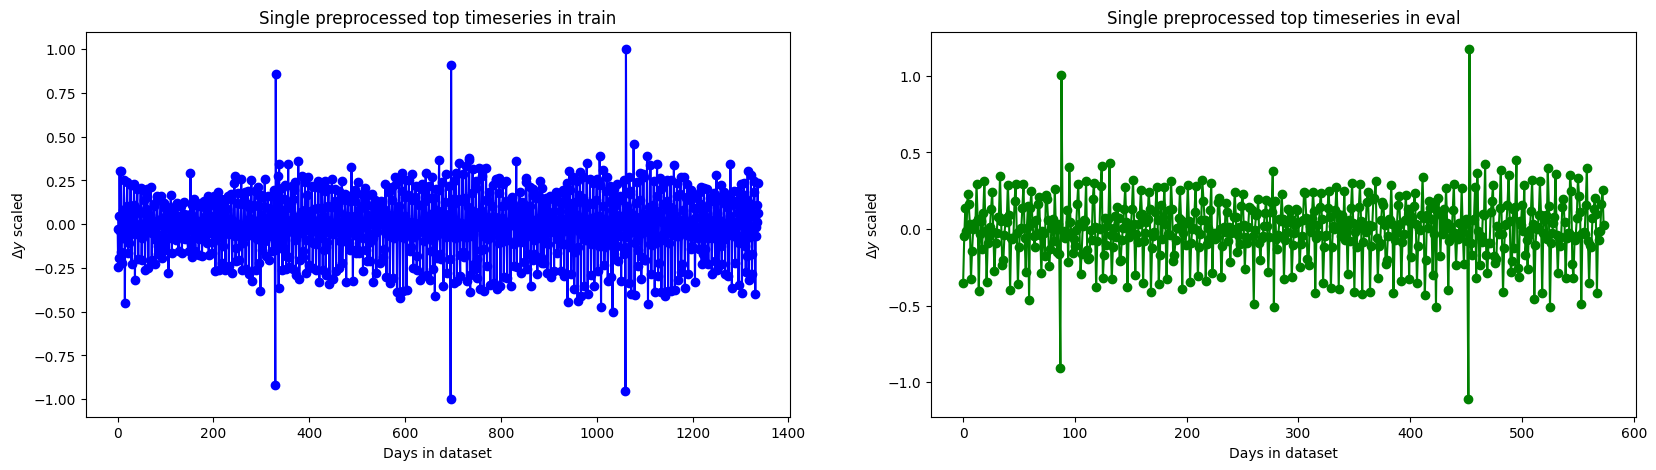

In [63]:
fig, ax = plt.subplots(1,2,figsize=(20,5))
ax[0].plot(scaled_train, '-o', c="b")
ax[1].plot(scaled_eval, '-o', c="g")
ax[0].set_title("Single preprocessed top timeseries in train")
ax[1].set_title("Single preprocessed top timeseries in eval");
ax[0].set_xlabel("Days in dataset")
ax[1].set_xlabel("Days in dataset")
ax[0].set_ylabel("$\Delta y$ scaled")
ax[1].set_ylabel("$\Delta y$ scaled");

In [64]:
seq_len = 400
input_dim = 1
hidden_dim = 128
num_epochs = 600
lr=0.0005


x_train, y_train = create_sequences(scaled_train, seq_len)
x_eval, y_eval = create_sequences(scaled_eval, seq_len)

x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()
x_eval = torch.from_numpy(x_eval).float()
y_eval = torch.from_numpy(y_eval).float()

data_dict = {"train": {"input": x_train, "target": y_train},
             "eval": {"input": x_eval, "target": y_eval}}

In [65]:
model = MyLSTM(input_dim=input_dim,
               hidden_dim=hidden_dim,
               batch_size=seq_len)
model = model.to(device)

/Users/zak/anaconda3/envs/DataCamp/lib/python3.11/site-packages/torch/nn/modules/rnn.py:123: UserWarning:

dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1



In [66]:
run_training = True
if run_training:
    losses_dict, predictions_dict = train_model(model, data_dict, num_epochs=num_epochs, lr=lr)

train loss: 0.03483964502811432
eval loss: 0.0564255565404892
train loss: 0.029862847179174423
eval loss: 0.051567837595939636
train loss: 0.018063344061374664
eval loss: 0.03916230425238609
train loss: 0.017035841941833496
eval loss: 0.037513770163059235
train loss: 0.015622474253177643
eval loss: 0.03452049568295479
train loss: 0.011520788073539734
eval loss: 0.02661004289984703
train loss: 0.01141364686191082
eval loss: 0.02567632496356964
train loss: 0.011322464793920517
eval loss: 0.02511616051197052
train loss: 0.011241959407925606
eval loss: 0.024557825177907944
train loss: 0.011171837337315083
eval loss: 0.02403072454035282
train loss: 0.011110923252999783
eval loss: 0.02355118654668331
train loss: 0.01105624157935381
eval loss: 0.023122597485780716


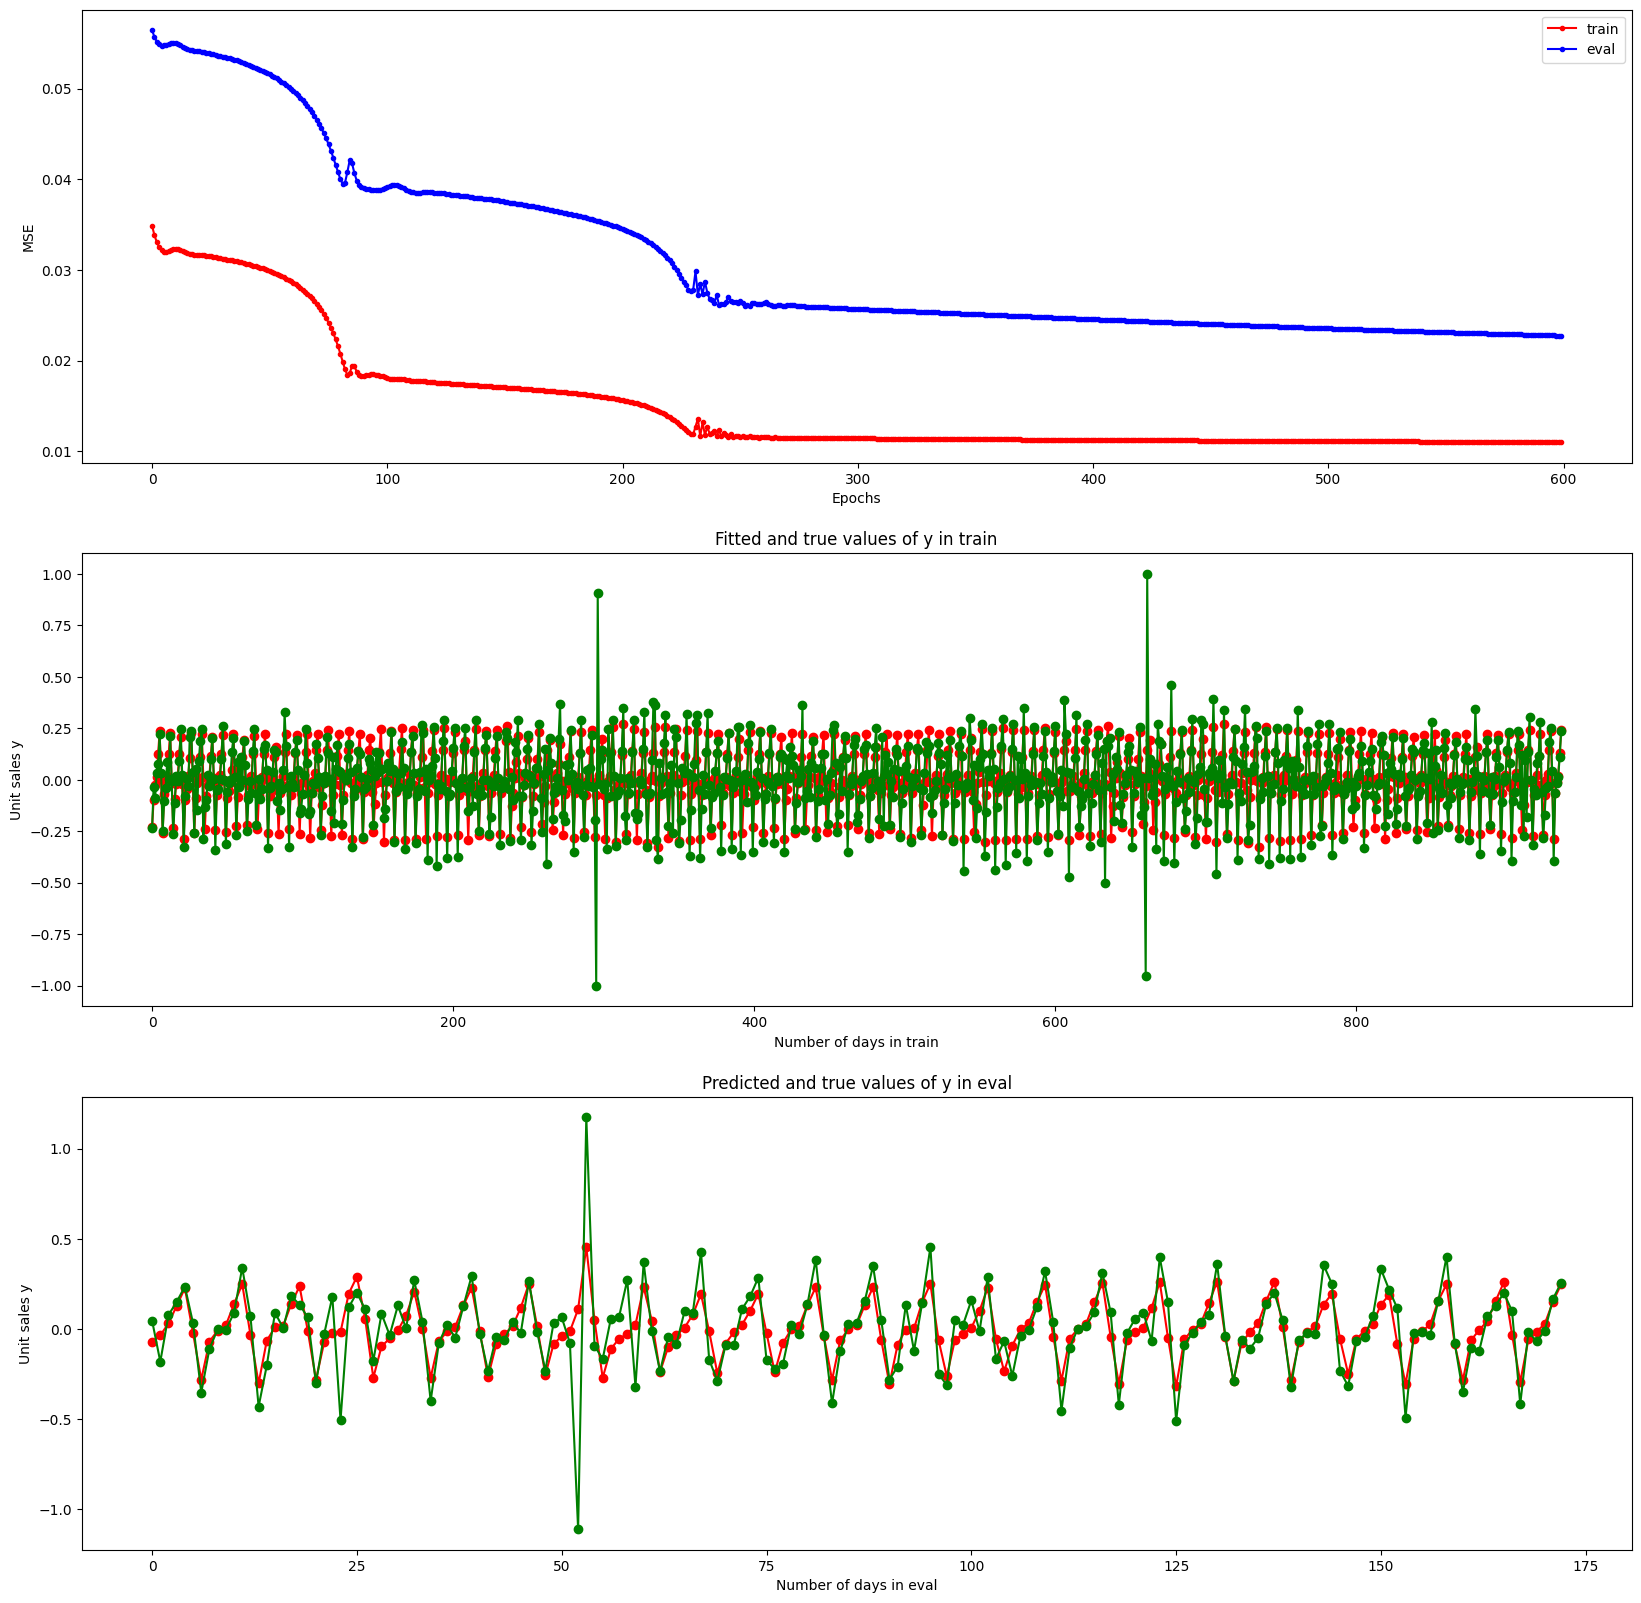

In [67]:
if run_training:
    
    fig, ax = plt.subplots(3,1,figsize=(20,20))
    ax[0].plot(losses_dict["train"], '.-', label="train", c="red")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("MSE")
    ax[0].plot(losses_dict["eval"], '.-', label="eval", c="blue");
    ax[0].legend();

    ax[1].plot(predictions_dict["train"], '-o', c="red")
    ax[1].plot(y_train, '-o', c="green")
    ax[1].set_title("Fitted and true values of y in train");
    ax[1].set_ylabel("Unit sales y");
    ax[1].set_xlabel("Number of days in train");

    ax[2].plot(predictions_dict["eval"], '-o', c="red")
    ax[2].plot(y_eval, '-o', c="green")
    ax[2].set_title("Predicted and true values of y in eval");
    ax[2].set_xlabel("Number of days in eval");
    ax[2].set_ylabel("Unit sales y");